In [2]:
import numpy as np
import csv

def generate_normal_csv(num_points, filename, x_min=-3, x_max=3):
    """
    Generates a list of x values and associated probabilities that approximate a normal distribution.
    
    Parameters:
        num_points (int): Number of points in the lists.
        filename (str): The output CSV file name.
        x_min (float): The minimum x-value (default is -3).
        x_max (float): The maximum x-value (default is 3).
    
    The CSV file will contain three rows:
        - Row 1: Indices starting from 1.
        - Row 2: x values (linearly spaced from x_min to x_max).
        - Row 3: Normalized probability values (summing to 1).
    """
    # Generate x values in the specified range
    x = np.linspace(x_min, x_max, num_points)
    
    # Calculate the standard normal probability density function (PDF) values
    pdf = np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)
    
    # Normalize the PDF so that the sum of probabilities equals 1
    pdf_normalized = pdf / np.sum(pdf)
    
    # Create an index list starting at 1
    indices = np.arange(1, num_points + 1)
    
    # Write the results to a CSV file with three rows
    with open(filename, "w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(indices)
        writer.writerow(x)
        writer.writerow(pdf_normalized)
    
    print(f"Data successfully written to {filename}")


In [3]:
path="/Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_jackpot.csv"
generate_normal_csv(5,path,0.05,0.15)

Data successfully written to /Users/khangvhuynh/prism-new/prism/tests/param_distr/param_p_jackpot.csv


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

def plot(csv_file, x_index, y_index, output_file):
    """
    Reads a CSV file and plots:
      - A bar graph for the specified x and y columns (selected by index)
      - A smooth (cubic spline) curve for the x-y data.
      
    Parameters:
        csv_file (str): Path to the CSV file.
        x_index (int): The index position of the column to use for x-values.
        y_index (int): The index position of the column to use for y-values.
    """
    # Read CSV file into a DataFrame.
    df = pd.read_csv(csv_file)
    
    # Retrieve the column names using the provided indices.
    x_col = df.columns[x_index]
    y_col = df.columns[y_index]
    
    # Extract the data for x and y.
    x = df[x_col].values
    y = df[y_col].values
    
    # Create the figure and axis.
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot the bar graph.
    ax.bar(x, y, alpha=0.5, label='Scatter Plot')
    
    # Prepare data for a smooth curve:
    # Sorting x (and y accordingly) to ensure proper interpolation.
    sort_idx = np.argsort(x)
    x_sorted = x[sort_idx]
    y_sorted = y[sort_idx]
    
    # Generate new x values (300 points for a smooth curve).
    x_new = np.linspace(np.min(x_sorted), np.max(x_sorted), 300)
    
    # Create a cubic spline of the sorted data.
    #spline = make_interp_spline(x_sorted, y_sorted, k=3)
    #y_smooth = spline(x_new)
    
    # Plot the smooth curve.
    #ax.plot(x_new, y_smooth, color='red', linewidth=2, label='Smooth Curve')
    
    # Set labels and title.
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title('BarGraph')
    ax.legend()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    # Display the plot.
    plt.show()

    

# Example usage:
# plot_csv_bar_and_smooth('data.csv', 0, 1)


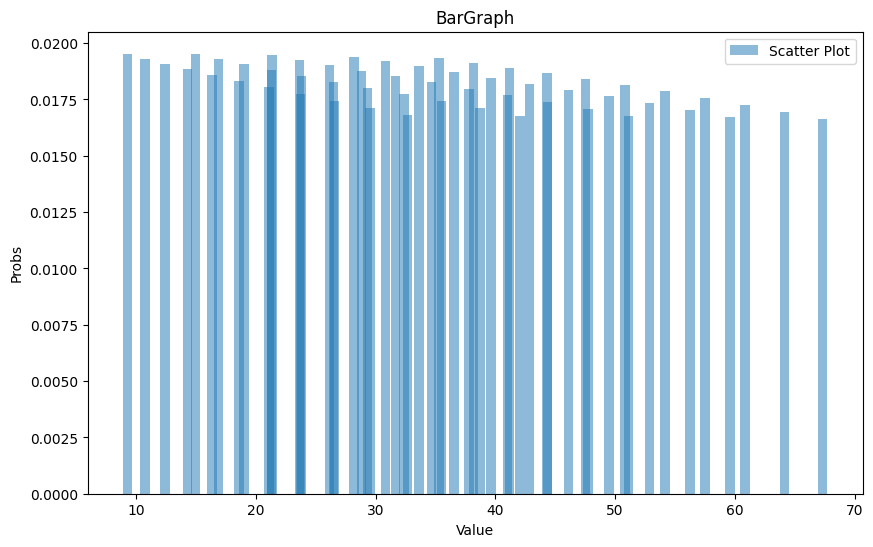

In [13]:
csv_file="/Users/khangvhuynh/prism-new/optimistic/betting_game_2_param_opt.csv"
output_file="/Users/khangvhuynh/prism-new/plot/basketball_g__opt_2_param.png"
plot(csv_file, 1, 2, output_file)

In [14]:
import pandas as pd
import numpy as np
from typing import Dict

def compute_statistics(file_path: str, value_col: int, prob_col: int) -> Dict[str, float]:
    # Read the CSV file
    df = pd.read_csv(file_path)

    # Extract the specified columns
    values = df.iloc[:, value_col].to_numpy()
    probabilities = df.iloc[:, prob_col].to_numpy()

    # Normalize probabilities if not already summing to 1
    probabilities = probabilities / np.sum(probabilities)

    # Compute central tendency metrics
    mean = np.sum(values * probabilities)
    median = np.interp(0.5, np.cumsum(probabilities), values)
    mode_index = np.argmax(probabilities)
    mode = values[mode_index]

    # Compute dispersion metrics
    variance = np.sum(((values - mean) ** 2) * probabilities)
    std_dev = np.sqrt(variance)
    value_range = np.max(values) - np.min(values)

    # Compute IQR
    cdf = np.cumsum(probabilities)
    q1 = np.interp(0.25, cdf, values)
    q3 = np.interp(0.75, cdf, values)
    iqr = q3 - q1

    # Compute skewness
    skewness = np.sum(((values - mean) ** 3) * probabilities) / (std_dev ** 3)

    # Compute kurtosis
    kurtosis = np.sum(((values - mean) ** 4) * probabilities) / (std_dev ** 4)

    # Compute entropy
    entropy = -np.sum(probabilities * np.log(probabilities + 1e-9))  # Adding a small value to avoid log(0)

    # Prepare result dictionary
    result = {
        "mean": mean,
        "median": median,
        "mode": mode,
        "variance": variance,
        "standard_deviation": std_dev,
        "range": value_range,
        "interquartile_range": iqr,
        "skewness": skewness,
        "kurtosis": kurtosis,
        "entropy": entropy
    }

    return result

In [15]:
betting_g_rob= "/Users/khangvhuynh/prism-new/robust/betting_game_rob_2_param.csv"
betting_g_opt = "/Users/khangvhuynh/prism-new/optimistic/betting_game_2_param_opt.csv"
betting_g_our = "/Users/khangvhuynh/prism-new/our/betting_game_2_param.csv"

value_col = 1
prob_col = 2

g_rob_result = compute_statistics(betting_g_rob, value_col, prob_col)
print("betting_g robust: \n")
for metric, value in g_rob_result.items():
    print(f"{metric}: {value}\n")
g_opt_result = compute_statistics(betting_g_opt, value_col, prob_col)
print("betting_g optimistic: \n")
for metric, value in g_opt_result.items():
    print(f"{metric}: {value}\n")
g_our_result = compute_statistics(betting_g_our, value_col, prob_col)
print("betting_g our: \n")
for metric, value in g_our_result.items():
    print(f"{metric}: {value}\n")

betting_g robust: 

mean: 34.42059109716053

median: 21.401177606582717

mode: 9.504268927263666

variance: 188.54022802452312

standard_deviation: 13.73099515783627

range: 54.679076911855475

interquartile_range: 19.44754956540823

skewness: 0.16940124024335243

kurtosis: 2.2097463712693584

entropy: 4.00620250869782

betting_g optimistic: 

mean: 34.82188652993988

median: 21.578807633951865

mode: 9.28472574549804

variance: 207.7261962881532

standard_deviation: 14.412709540129962

range: 58.03112503955862

interquartile_range: 21.243757279356327

skewness: 0.2502006990413971

kurtosis: 2.2821556662181988

entropy: 4.00620250869782

betting_g our: 

mean: 35.02114852176881

median: 21.70249172235431

mode: 9.37422178084179

variance: 206.30557339970875

standard_deviation: 14.363341303461

range: 57.59486463619922

interquartile_range: 20.934710197841063

skewness: 0.22351006918419186

kurtosis: 2.2554235841000043

entropy: 4.00620250869782

